<a href="https://colab.research.google.com/github/mariacgomez-tech/Analitica-de-Negocios/blob/main/3_Clustering_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de Estudio**
En este documento se desarrolla y se analiza un modelo Clustering K-Means mejorar para la PreAprobación de créditos en una entidad financiera utilizando las variaboles socioeconómicas de un solicitante de crédito. De acuerdo con lo anterior, las variables socioeconómicas son:

Edad: Es la edad que posee el solicitante al momento de solicitar un crédito.

Ingresos: Ingresos recibidos por una persona como resultado de una actividad comercial.

Egresos: Son los gastos mensuales del solicitante. Gastos de personas a cargo, hijos y servicios públicos.

Monto (EAD): Indica el dinero que una persona solicita a una entidad financiera como crédito.

0. Se procede con la carga de las librerías de trabajo

In [ ]:
import numpy as np #Librería numérica por excelencia. (pongo np para no tener que seguirla escribiendo)
import pandas as pd #Librería para la comunicación con archivos de excel
import matplotlib.pyplot as plt
import seaborn as sns #Herramientas para gráficas estadisticas
from sklearn.cluster import KMeans #Herramienta de clustering

1. Se cargan datos de trabajo

<Axes: >

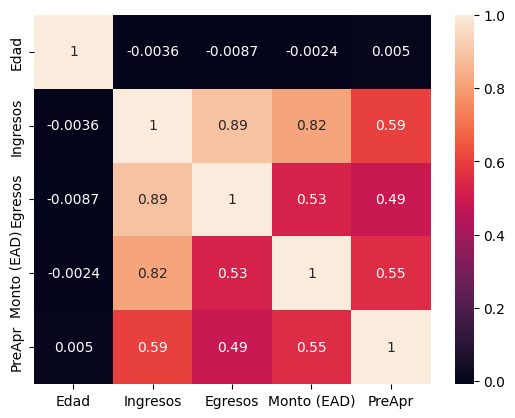

In [ ]:
nxl= '/content/sample_data/1. SolicitantesCrédito(USD).xlsx'
XDB=pd.read_excel(nxl, sheet_name=1) #Base AAA
XD=XDB.iloc[:,[1,10,11,25]] #Datos de entrada
yd=XDB.iloc[:,32]

#Determinemos la correlación entre las variables
XDB2=XDB.iloc[:,[1,10,11,25,32]]
sns.heatmap(XDB2.corr(), annot=True)

2. Se proecese con la implementación del modelo K-Means

In [ ]:
np.random.seed(42) #Esto permite generar las mismas semillas para todos
NC=5 #Segmentos o perfiles de cliente
mkm=KMeans(n_clusters=NC, random_state=42)
mkm.fit(XD, yd) #El modelo busca la mejor relación entre la entrada y la salida

#Obtenemos las caracteristicas de cada grupo
#Representa los perfiles de las personas mkm.cluster_centers_ que encontró el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)
display(Tabla)

#Para saber los porcentajes de PreApr o PreNeg por segmento, sucursal, o perfil
ydp=mkm.labels_ #Esto me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp) #Esto me indica cuantos datos hay en cada cluster (#datos por segmento)
print('El número de datos por cluster es: ', NDc)

,Edad,Ingresos,Egresos,Monto (EAD)
0,41.062353,242.798352,213.255141,175.381339
1,40.814394,1943.037897,2034.368232,1151.374380
2,40.842975,1378.277280,825.976626,1500.438821
3,40.995816,1173.957912,1239.367737,656.163350
4,41.129177,711.127537,601.939361,537.170724


El número de datos por cluster es:  [2127  264  485  960 2006]


3. Porcentajes de PreApr

In [ ]:
XDB2['Cluster']=ydp
display(XDB2)

#Determinar el número de preApro y preNeg por Cluster
NApr=XDB2.groupby('Cluster').agg({"PreApr": lambda x: (x==1).sum()})
NPrn=XDB2.groupby('Cluster').agg({"PreApr": lambda x: (x==0).sum()})
df2=pd.DataFrame(np.column_stack((NApr, NPrn)),columns=['PreApr','PreNeg'])
display(df2)

#Para que la decición sea en porcentaje
NApr2=NApr/(NApr+NPrn); NPrn2=NPrn/(NApr+NPrn)
df2=pd.DataFrame(np.column_stack((NApr2, NPrn2)),columns=['PreApr','PreNeg'])
display(df2)

/tmp/ipython-input-272/4193185454.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2['Cluster']=ydp


,Edad,Ingresos,Egresos,Monto (EAD),PreApr,Cluster
0,38,1356.14400,1685.622667,625.562230,1,3
1,51,286.01600,364.462000,140.031984,1,0
2,37,517.46325,629.208889,284.564492,0,4
3,29,473.27000,551.616889,309.647588,1,4
4,42,750.09175,806.715778,500.663578,1,4
...,...,...,...,...,...,...
5837,48,1207.84800,753.801111,748.041791,1,3
5838,31,1472.77200,953.812889,870.793819,1,3
5839,38,773.01975,672.910667,594.947894,1,4
5840,43,635.50175,780.691556,305.580539,1,4


,PreApr,PreNeg
0,292,1835
1,254,10
2,472,13
3,742,218
4,1123,883


,PreApr,PreNeg
0,0.137283,0.862717
1,0.962121,0.037879
2,0.973196,0.026804
3,0.772917,0.227083
4,0.559821,0.440179


4. ¿Qué pasa si aparece una nueva persona?
Edad: 30, Ingresos: 500, Egresos:200, Monto:150

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

nueva_persona=np.array([[30,500,200,150]])
ydp=mkm.predict(nueva_persona.reshape(1,-1)) #reshape: quitarle la estructura
NCl=ydp[0] #Esto indica el cluster al que pertenece una persona
print("La persona pertenece al cluster:", ydp)
print("El porcentaje de preaprobación para la nueva persona es: ", NApr2.iloc[NCl])
print("El porcentaje de preNegación para la nueva persona es: ", NPrn2.iloc[NCl])

La persona pertenece al cluster: [0]
El porcentaje de preaprobación para la nueva persona es:  PreApr    0.137283
Name: 0, dtype: float64
El porcentaje de preNegación para la nueva persona es:  PreApr    0.862717
Name: 0, dtype: float64


5. Se procede con la gráfica de los clusters utilizando las variables Ingresos, Egresos (las que estuvieron más correlacionadas)

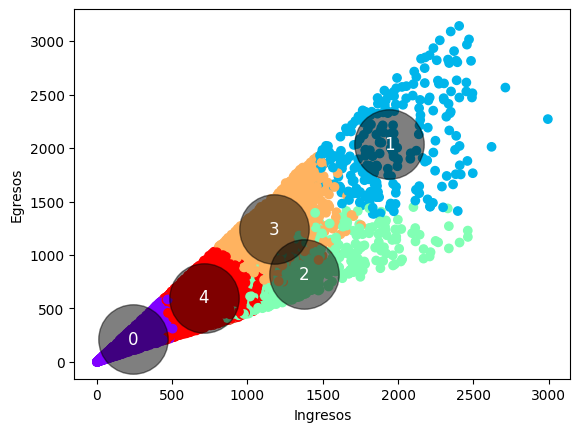

In [ ]:
centers=mkm.cluster_centers_ #Centroides, Perfil o segmento
ing=np.array(XD.iloc[:,1]); egr=np.array(XD.iloc[:,2]) #Ingresos y Egresos

plt.figure()
plt.scatter(ing,egr,c=mkm.labels_, cmap='rainbow')
plt.scatter(centers[:,1], centers[:,2], c='black', s=2500, alpha=0.5)
plt.xlabel('Ingresos')
plt.ylabel('Egresos')

#Añade números a los circulos
for i, center in enumerate(centers):
    plt.text(center[1], center[2], str(i), color='white', fontsize=12, ha='center', va='center')

plt.show()

**Análisis de Resultados**
En el heatmap se puede observar que las variable sque tienen mayor correlación entre ellas son las variables de ingresos y egresos con 89%. Esto indica que si una variable aumenta su valor, la otra también se incrementa (si gano mucho, gasto mucho). Otra correlación de relevancia es la correlación entre ingresos y monto (0.82), las personas con altos ingresos, piden montos mayores (bajos ingresos-montos menores). Se destaca que la variable que tiene una mayor correlación con la variable preApr (salida) es la variable ingresos (59%). (Buenas correlaciones se dan desde el 75% pero en ciertas ocasiones también se puede considerar desde el 50%)

De acuerdo con los segmentos o clusters arrojados por el modelo, podemos observar que el cluster 1 y el cluster 2 son los que poiseen los ingresos más altos 1943 y 1378 respectivamente, clusters que igualmente son los que tienen la menor cantidad de solicitantes de crédito con 264 y 485 respectivamente. Se destaca el primer cluster, el cual agrupa a las personas con menos ingresos (242), pero es el grupo que posee la mayor cantidad de solicitantes de crédito.

Se puede observar que el cluster 1 y el cluster 2, agrupan las probabilidades más altas frente a la preApr de los crédito con un 96% y 97% de PreAprobación respectivamente. Es importante mencionar que el cluster 0 tuvo los menores porcentajes de PreAprobación, esto promovido por los menores ingresos para las personas que hacen parte de este cluster.